In [3]:
%matplotlib inline


Using device: cuda
Number of training images: 60000
Number of testing images: 10000


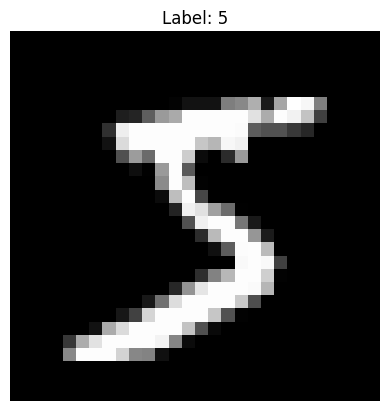

DigitClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Starting training...

Epoch [1/5], Loss: 0.3757
Epoch [2/5], Loss: 0.1741
Epoch [3/5], Loss: 0.1287
Epoch [4/5], Loss: 0.1062
Epoch [5/5], Loss: 0.0888

Test Accuracy: 97.59%


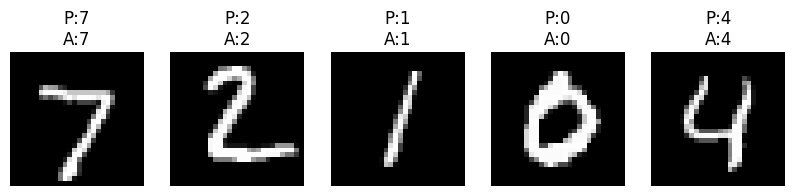


Model saved as mnist_pytorch_model.pth
Model loaded successfully


In [4]:



# IMPORTING LIBRARIES


# PyTorch main library
import torch

# Neural network module
import torch.nn as nn

# Optimization algorithms
import torch.optim as optim

# Dataset utilities and image transforms
import torchvision
import torchvision.transforms as transforms

# For displaying images
import matplotlib.pyplot as plt

# NumPy for numerical operations
import numpy as np



# CHECKING IF GPU IS AVAILABLE




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")



# DEFINING IMAGE TRANSFORMATIONS



transform = transforms.ToTensor()



# DOWNLOADING AND LOADING THE MNIST DATASET


train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)



# CREATING DATA LOADERS



train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)


# DISPLAYING DATASET INFORMATION


print(f"Number of training images: {len(train_dataset)}")
print(f"Number of testing images: {len(test_dataset)}")



# DISPLAYING A SAMPLE IMAGE


sample_image, sample_label = train_dataset[0]

image = sample_image.squeeze().numpy()

plt.imshow(image, cmap='gray')
plt.title(f"Label: {sample_label}")
plt.axis('off')
plt.show()



# DEFINING THE NEURAL NETWORK



class DigitClassifier(nn.Module):

    def __init__(self):
        super(DigitClassifier, self).__init__()


        self.flatten = nn.Flatten()


        self.fc1 = nn.Linear(28 * 28, 128)


        self.relu = nn.ReLU()


        self.dropout = nn.Dropout(0.2)

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.flatten(x)


        x = self.fc1(x)


        x = self.relu(x)


        x = self.dropout(x)


        x = self.fc2(x)

        return x



# CREATNG MODEL INSTANCE


model = DigitClassifier().to(device)

print(model)


# DEFINING LOSS FUNCTION AND OPTIMIZER


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)



# TRAINING THE MODEL


epochs = 5

print("\nStarting training...\n")

for epoch in range(epochs):


    model.train()

    running_loss = 0.0


    for images, labels in train_loader:


        images = images.to(device)
        labels = labels.to(device)


        optimizer.zero_grad()


        outputs = model(images)


        loss = criterion(outputs, labels)


        loss.backward()


        optimizer.step()


        running_loss += loss.item()


    print(
        f"Epoch [{epoch+1}/{epochs}], "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )



# TESTING THE MODEL



model.eval()

correct = 0
total = 0


with torch.no_grad():

    for images, labels in test_loader:


        images = images.to(device)
        labels = labels.to(device)


        outputs = model(images)


        _, predicted = torch.max(outputs.data, 1)


        total += labels.size(0)


        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"\nTest Accuracy: {accuracy:.2f}%")



# MAKING PREDICTIONS ON SAMPLE TEST IMAGES



examples = iter(test_loader)

images, labels = next(examples)

images = images.to(device)


outputs = model(images)


_, predictions = torch.max(outputs, 1)


images = images.cpu()
predictions = predictions.cpu()



# DISPLAYING PREDICTIONS


plt.figure(figsize=(10, 3))

for i in range(5):

    plt.subplot(1, 5, i + 1)


    image = images[i].squeeze().numpy()

    plt.imshow(image, cmap='gray')

    plt.title(
        f"P:{predictions[i].item()}\nA:{labels[i].item()}"
    )

    plt.axis('off')

plt.show()



# SAVING THE MODEL




torch.save(model.state_dict(), "mnist_pytorch_model.pth")

print("\nModel saved as mnist_pytorch_model.pth")



# LOADING THE MODEL
# THIS PREVENTS RETRAINING THE WHOLE MODEL AFTER WE HAVE ALREADY RETRAINED IT




model = DigitClassifier()
model.load_state_dict(torch.load("mnist_pytorch_model.pth"))
model.eval()

print("Model loaded successfully")


In [5]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [6]:
from google.colab import files
files.download("mnist_pytorch_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>